In [2]:
import numpy as np 
import pandas as pd
import io
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn. ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier


import matplotlib.pyplot as plt, seaborn as sns

  
  

In [3]:
#read file

df = pd.read_csv("machine_ID_7.csv")

del df["Unnamed: 0"]

In [4]:
#saving dataframe on a different name

ds = df

ds =df.drop(['datetime'], axis=1)
ds =ds.drop(['time_diff'], axis=1)
ds =ds.drop(['model'], axis=1)
ds =ds.drop(['age'], axis=1)
ds =ds.drop(['machineID'], axis=1)
ds =ds.drop(['error1count'], axis=1)
ds =ds.drop(['error2count'], axis=1)
ds =ds.drop(['error3count'], axis=1)
ds =ds.drop(['error4count'], axis=1)
ds =ds.drop(['error5count'], axis=1)
ds =ds.drop(['failure'], axis=1)

ds.head(2)

,voltmean,rotatemean,pressuremean,vibrationmean,voltsd,rotatesd,pressuresd,vibrationsd
0,173.004557,463.190750,102.947943,40.474100,16.414778,53.033936,6.719689,5.471629
1,173.815784,458.194043,103.965293,39.846163,15.232968,52.831228,8.902306,4.650268


In [5]:
wei_avg = pd.read_csv("wei_avg_m2.csv")
del wei_avg["Unnamed: 0"]
wei_avg

,wei_voltmean,failure,wei_rotatemean,wei_pressuremean,wei_vibrationmean,wei_voltsd,wei_rotatesd,wei_vibrationsd,wei_pressuresd
0,171.510408,False,449.677759,98.073274,41.570134,11.840965,44.617316,4.948928,9.883569
1,170.840565,False,441.775812,97.834623,41.161236,11.170166,51.726172,5.416448,9.633262
2,170.736634,False,439.437013,98.414950,40.874904,12.334993,51.861538,5.676570,9.961815
3,169.596900,False,442.871050,97.365553,41.387017,11.630878,54.084602,5.420041,9.756610
4,170.388162,False,445.438537,96.262632,41.273377,10.565470,51.662631,5.699011,10.507463
...,...,...,...,...,...,...,...,...,...
2905,168.569131,False,455.106349,101.053880,38.782146,14.365550,50.712992,5.473602,10.849184
2906,167.717768,False,451.457061,102.737289,39.623704,13.987749,51.699255,5.922676,11.985588
2907,166.569083,False,458.292778,100.631192,40.234731,14.144781,46.359921,5.702438,10.638965
2908,166.899065,False,454.400463,101.066046,40.221803,14.348292,44.121765,5.360968,10.671764


In [6]:
y = wei_avg.failure
X = wei_avg.drop('failure', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)


In [7]:
rf = RandomForestClassifier(n_estimators=35)
rf.fit(X_train,y_train)
rf.score(X_test,y_test)

0.993127147766323

In [8]:
#Predict the response for test dataset
y_pred = rf.predict(X_test)

In [9]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[575,   0],
       [  4,   3]], dtype=int64)

In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.99      1.00      1.00       575
        True       1.00      0.43      0.60         7

    accuracy                           0.99       582
   macro avg       1.00      0.71      0.80       582
weighted avg       0.99      0.99      0.99       582



Text(0.5, 257.44, 'Predicted label')

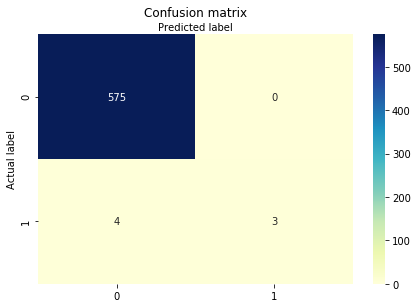

In [11]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')